## **Práctica 2:  Modelo cinemático inverso de un manipulador y planteamiento de trayectoria**

**Integrantes del equipo:** 
* Espitia Castellanos Nicol 

* Minero Fujigaki Paris Alejandro

* López González Alejandro

### **1. Objetivo**

<div style="text-align: justify;">
El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa de un manipualdor serial.
</div>

<div style="text-align: justify;">

### **2. Cuestionario previo**

* **¿Qué son las transformaciones homogéneas?** 

Son matrices matemáticas que permiten representar simultáneamente la posición y orientación de un objeto o sistema de coordenadas en el espacio, respecto al sistema de referencia de una junta anterior. Esta herramienta permite realizar el planteamiento cinemático de un robot.

* **¿Qué nos permite obtener el modelo de cinemática directa de un manipulador?**

Permite obtener las ecuaciones para determinar la posición, orientación y velocidad del efector final a partir de los valores de posición y velocidad de las juntas del robot.

* **¿Qué nos permite obtener el modelo de cinemática inversa de un manipualdor?** 

El modelo de cinemática inversa de un manipulador permite obtener los valores de posición y velocidad de las juntas del robot a partir de la posición, orientación y velocidad deseadas del efector final.

* **¿De qué forma se puede interpolar la trayectoria de un efector final entre dos puntos?**

A partir de la implementación de un spline, el cual corresponde a una función polinomial que permite generar trayectorias suaves y continuas entre dos o más puntos, asegurando transiciones graduales en la posición y velocidad del efector final. </div>


### **3. Desarrollo**

#### **3.1. Planteamiento de la cinemática directa**

En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. 

![Robot a realizar practica 2](imagenes/p2_1.png)

In [16]:
#!/usr/bin/env python3
from sympy import *
import matplotlib.pyplot as plt

In [17]:
class Robot():

  # Se establecen desde el inicio las longitudes de los eslabones en forma de una tupla 
  def __init__(self, l:tuple[float]=(0.3, 0.3, 0.3)):
    # Variables simbólicas para los ángulos de cada una de las 3 juntas (articulaciones)
    th1, th2, th3 = symbols("theta_1,theta_2,theta_3")

    # Llamamos a la función para crear las matrices de transformación pasándole el parámetro necesario 
    # Transformación del sistema base al primer eslabón (rotación de 90° en X y rotación articular en Z)
    T_0_1 = self.tr_h(gamma=pi/2,
                      alpha=th1)
    # Transformación del eslabón 1 al 2 (traslación por la longitud l[0] y rotación articular en Z)
    T_1_2 = self.tr_h(x = l[0],
                      alpha=th2)
    # Transformación del eslabón 2 al 3 (traslación por la longitud l[1] y rotación articular en Z)
    T_2_3 = self.tr_h(x = l[1],
                      alpha=th3)
    # Transformación del eslabón 3 al Efector Final (solo traslación por la longitud l[2])
    T_3_p = self.tr_h(x=l[2])

    # Se multiplican las matrices para obtener la transformación total de la base al efector final
    T_0_p = T_0_1 * T_1_2 * T_2_3 * T_3_p
    # Se simplifica algebraicamente la matriz resultante
    T_0_p = simplify(T_0_p)
    
    # Vector de postura: extrae la posición X (renglón 0), Z (renglón 2) y la suma total de los ángulos
    xi_0_p = Matrix([T_0_p[0, 3],
                     T_0_p[2, 3],
                     th1 + th2 + th3])
                     
    # Jacobiano: Matriz de derivadas parciales del vector de postura respecto a cada ángulo articular
    J = Matrix([[diff(xi_0_p, th1),
                 diff(xi_0_p, th2),
                 diff(xi_0_p, th3)]])
    # Se calcula la inversa del Jacobiano, necesaria más adelante para la cinemática inversa diferencial
    J_inv = J.inv()

    # Velocidades espaciales del Efector Final (E.F.) declaradas como variables simbólicas
    x_dot, z_dot, beta_dot = symbols("x_dot, z_dot, beta_dot")
    
    # Construir polinomio lambda (polinomio de 5to grado para interpolación de la trayectoria)
    t = symbols("t")
    a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
    lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5    
    
    # Primera derivada del polinomio (representa el perfil de velocidad)
    lam_dot = diff(lam, t)
    # Segunda derivada del polinomio (representa el perfil de aceleración)
    lam_dot_dot = diff(lam_dot, t)
    
    # Almacenar las variables simbólicas y los modelos calculados en el objeto para usarlos en otros métodos
    self.th1, self.th2, self.th3 = th1, th2, th3
    self.xi_0_p = xi_0_p
    self.J_inv = J_inv
    self.x_dot, self.z_dot, self.beta_dot = symbols("x_dot, z_dot, beta_dot")
    self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5 = a_0, a_1, a_2, a_3, a_4, a_5
    self.t = t
    self.lam, self.lam_dot, self.lam_dot_dot = lam, lam_dot, lam_dot_dot

  # Se crea una función auxiliar para realizar la construcción de las matrices de transformación en X, Y y Z
  # En caso de que alguno de los valores no se asigne la distancia y el ángulo se toman como 0
  def tr_h(self, x=0, y=0, z=0, gamma=0, beta=0, alpha=0):

    # Matriz de transformación para X (incluye traslación en el eje X y rotación Gamma)
    t_x = Matrix([[1,          0,           0, x],
                  [0, cos(gamma), -sin(gamma), 0],
                  [0, sin(gamma),  cos(gamma), 0],
                  [0,          0,           0, 1]])

    # Matriz de transformación para Y (incluye traslación en el eje Y y rotación Beta)
    t_y = Matrix([[ cos(beta),          0, sin(beta), 0],
                  [         0,          1,         0, y],
                  [-sin(beta),          0, cos(beta), 0],
                  [         0,          0,         0, 1]])
    
    # Matriz de transformación para Z (incluye traslación en el eje Z y rotación Alpha)
    t_z = Matrix([[cos(alpha), -sin(alpha), 0, 0],
                  [sin(alpha),  cos(alpha), 0, 0],
                  [         0,           0, 1, z],
                  [         0,           0, 0, 1]])
                  
    # Se multiplican las tres matrices individuales para conformar la transformación homogénea 3D completa
    tr = simplify(t_x * t_y * t_z)
    return tr


In [18]:
# Instanciamos el robot 
robot = Robot()

<div style="text-align: justify;">

#### **3.2. Planteamiento de la trayectoria**

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

</div>

In [19]:
# Se define el método para calcular EXCLUSIVAMENTE la trayectoria del Efector Final
def def_tray(self, t_f:float=2, frec:float=30, 
              th_i:tuple[float]=(0.1, 0.1,0.1), 
              xi_f:tuple[float]=(0.6, 0.1, 0)):
  
  # Guardamos los ángulos iniciales en la clase para usarlos en el siguiente paso
  self.th_i = th_i
  
  # Posición inicial del efector final sustituyendo los ángulos iniciales en la ecuación de postura
  xi_i = self.xi_0_p.subs({self.th1: th_i[0], 
                            self.th2: th_i[1], 
                            self.th3: th_i[2]})
                            
  # Cálculo del periodo de muestreo (dt) y cantidad de muestras
  self.dt = 1.0/frec
  self.muestras = int(t_f * frec + 1) 

  # Ecuaciones de restricción para la trayectoria (Condiciones de frontera nulas al inicio y fin)
  eq1 = self.lam.subs({self.t: 0})
  eq2 = self.lam.subs({self.t: t_f}) - 1
  eq3 = self.lam_dot.subs({self.t: 0})
  eq4 = self.lam_dot.subs({self.t: t_f})
  eq5 = self.lam_dot_dot.subs({self.t: 0})
  eq6 = self.lam_dot_dot.subs({self.t: t_f})
  
  # Resolución del sistema de ecuaciones para encontrar los coeficientes a_0 hasta a_5
  solutions = solve((eq1, eq2, eq3, eq4, eq5, eq6),
                (self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5))
                
  # Sustituyendo la solución (coeficientes) en los polinomios lambda originales
  lam_s         = self.lam.subs(solutions)
  lam_dot_s     = self.lam_dot.subs(solutions)
  lam_dot_dot_s = self.lam_dot_dot.subs(solutions)
  
  # Ecuación paramétrica de posiciones, velocidades y aceleraciones espaciales en función de lambda
  xi_f = Matrix([xi_f[0], xi_f[1], xi_f[2]])
  xi_eq         = xi_i + (xi_f - xi_i) * lam_s         
  xi_dot_eq     = (xi_f - xi_i) * lam_dot_s            
  xi_dot_dot_eq = (xi_f - xi_i) * lam_dot_dot_s        
  
  # Arreglos matriciales de ceros para almacenar el muestreo
  t_m = Matrix.zeros(1, self.muestras)
  for i in range(self.muestras):
    t_m[i] = self.dt * i
    
  xi_m         = Matrix.zeros(3, self.muestras)
  xi_dot_m     = Matrix.zeros(3, self.muestras)
  xi_dot_dot_m = Matrix.zeros(3, self.muestras)
  
  # Muestreo iterativo del E.F. evaluando las ecuaciones para cada instante de tiempo 't'
  for i in range(self.muestras):
    xi_m[:, i]         = xi_eq.subs({self.t: t_m[i]})
    xi_dot_m[:, i]     = xi_dot_eq.subs({self.t: t_m[i]})
    xi_dot_dot_m[:, i] = xi_dot_dot_eq.subs({self.t: t_m[i]})
    
  print("Última muestra de trayectoria calculada del E.F.:")
  print(xi_m[:, self.muestras - 1])
  
  # Guardar TODAS las variables calculadas en 'self' para que la cinemática inversa pueda acceder a ellas
  self.xi_m         = xi_m
  self.xi_dot_m     = xi_dot_m
  self.xi_dot_dot_m = xi_dot_dot_m
  self.t_m          = t_m

# Ligamos la función a la clase Robot
Robot.def_tray = def_tray

<div style="text-align: justify;"> 

#### **3.3 Cinemática Inversa**

A partir del modelo de la cinemática directa, obtener la expresión e la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

</div>

In [20]:

# Definimos el método para calcular la Cinemática Inversa Diferencial de las juntas
def cinematica_inversa(self):
  # Se plantea la ecuación diferencial: Vector_Vel_Articular = (Jacobiano_Inverso) * Vector_Vel_Cartesiana
  th_dot_eq = self.J_inv * Matrix([self.x_dot, 
                                   self.z_dot,
                                   self.beta_dot])
                                   
  # Matrices para almacenar Posición, Velocidad y Aceleración de las juntas
  th_m         = Matrix.zeros(3, self.muestras)
  th_dot_m     = Matrix.zeros(3, self.muestras)
  th_dot_dot_m = Matrix.zeros(3, self.muestras)
  
  # Recuperamos los ángulos iniciales guardados en la función anterior para t=0
  th_m[:, 0] = Matrix([self.th_i[0], 
                       self.th_i[1], 
                       self.th_i[2]])
                        
  # Bucle numérico iterativo para mapear variables cartesianas a articulares
  for i in range(self.muestras):
    # 1. Velocidades
    th_dot_m[:, i] = th_dot_eq.subs({
      self.th1: th_m[0, i],
      self.th2: th_m[1, i],
      self.th3: th_m[2, i],
      self.x_dot:    self.xi_dot_m[0, i], # Extraemos la velocidad del E.F. calculada previamente
      self.z_dot:    self.xi_dot_m[1, i],
      self.beta_dot: self.xi_dot_m[2, i]})
    th_dot_m[:, i] = th_dot_m[:, i].evalf() 
    
    # 2. Posiciones por Integración de Euler
    if i < self.muestras - 1:
      th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * self.dt
      
    # 3. Aceleraciones por Diferenciación Numérica
    if not (i == 0):
      th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1]) / self.dt
    
  # Guardar variables de las Juntas en la clase 
  self.th_m         = th_m
  self.th_dot_m     = th_dot_m
  self.th_dot_dot_m = th_dot_dot_m

# Ligamos la función a la clase Robot
Robot.cinematica_inversa = cinematica_inversa

<div style="text-align: justify;"> 

#### **3.4 Aplicación de la cinematica Inversa**

Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

</div>

Última muestra de trayectoria calculada del E.F.:
Matrix([[0.599999999999999], [0.100000000000000], [0]])


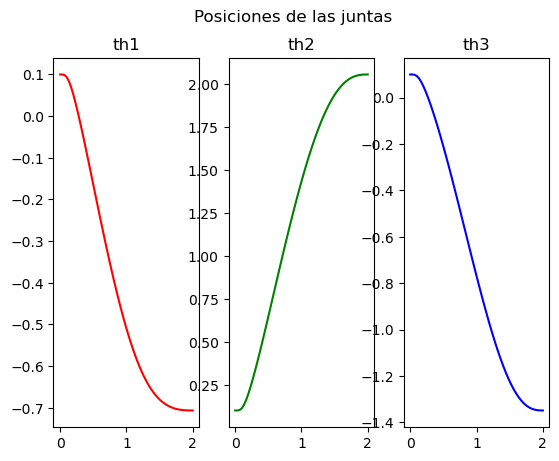

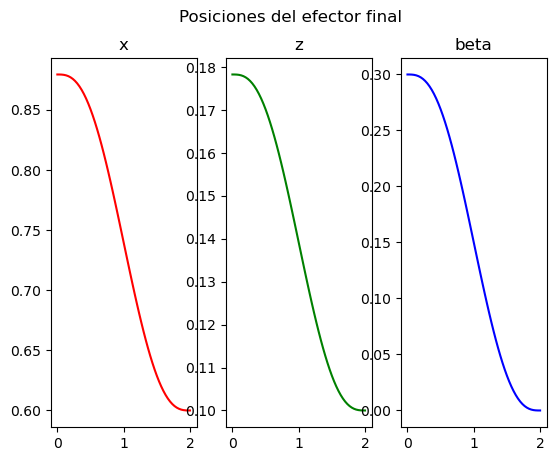

In [22]:
# Definición del método para desplegar gráficamente el espacio cartesiano/operacional (Efector Final)
def imp_tray(self):
    # plt.subplots() crea una ventana (fig) y la divide en subgráficas.
    # Se genera 1 fila y 3 columnas, asignando cada espacio a x_g, z_g y be_g respectivamente.
    fig, (x_g, z_g, be_g) = plt.subplots(nrows = 1, ncols = 3)
    
    # fig.suptitle() coloca un título principal centrado en la parte superior de toda la ventana
    fig.suptitle("Posiciones del efector final")
    
    # .set_title() le asigna un título individual a cada una de las 3 subgráficas
    x_g.set_title("x")
    z_g.set_title("z")
    be_g.set_title("beta")
    
    # Se plotean los datos: .plot(Eje_X, Eje_Y, color)
    # Se usa .T (Transpuesta) en las matrices para alinear las dimensiones de los datos y que matplotlib los entienda.
    # Gráfica 1: Tiempo vs Posición X (renglón 0 de xi_m) en color rojo
    x_g.plot(self.t_m.T,  self.xi_m[0, :].T, color="RED")
    
    # Gráfica 2: Tiempo vs Posición Z (renglón 1 de xi_m) en color verde
    z_g.plot(self.t_m.T,  self.xi_m[1, :].T, color="green")
    
    # Gráfica 3: Tiempo vs Orientación Beta (renglón 2 de xi_m) en color azul (formato RGB: 0,0,1)
    be_g.plot(self.t_m.T, self.xi_m[2, :].T, color=(0,0,1))
    
    # Comando obligatorio para renderizar la ventana y mostrar las gráficas en pantalla (o en el Jupyter Notebook)
    plt.show()

# Definición del método para desplegar gráficamente el espacio articular (movimiento de las juntas)
def imp_junt(self):
    # plt.subplots() genera la ventana principal (fig) y la divide en 3 espacios (1 fila y 3 columnas).
    # Cada espacio se asigna a las variables th1_g, th2_g y th3_g para controlarlos individualmente.
    fig, (th1_g, th2_g, th3_g) = plt.subplots(nrows = 1, ncols = 3)
    
    # fig.suptitle() establece el título principal que abarca toda la ventana de gráficos
    fig.suptitle("Posiciones de las juntas")
    
    # .set_title() asigna un título específico a cada subgráfica para identificar qué junta se está mostrando
    th1_g.set_title("th1")
    th2_g.set_title("th2")
    th3_g.set_title("th3")
    
    # Se plotean los datos usando .plot(Eje_X, Eje_Y, color)
    # Al igual que en la gráfica anterior, usamos .T (Transpuesta) para que los vectores se alineen correctamente.
    # Gráfica 1: Tiempo vs Ángulo de la Junta 1 (renglón 0 de la matriz th_m) en color rojo
    th1_g.plot(self.t_m.T,  self.th_m[0, :].T, color="RED")
    
    # Gráfica 2: Tiempo vs Ángulo de la Junta 2 (renglón 1 de la matriz th_m) en color verde
    th2_g.plot(self.t_m.T,  self.th_m[1, :].T, color="green")
    
    # Gráfica 3: Tiempo vs Ángulo de la Junta 3 (renglón 2 de la matriz th_m) en color azul (formato RGB: 0,0,1)
    th3_g.plot(self.t_m.T,  self.th_m[2, :].T, color=(0,0,1))
    
    # Renderiza la figura y la muestra en la pantalla
    plt.show()

Robot.imp_junt = imp_junt
Robot.imp_tray = imp_tray

robot.def_tray()
robot.cinematica_inversa()

robot.imp_junt() # Muestra gráficas de las juntas mediante cinemática inversa
robot.imp_tray() # Muestra gráficas del efector final

<div style="text-align: justify;">

### **4. Analisis de resultados**

* **¿Qué utilidad tiene el modelo de la cinématica inversa de un robot?**

A grandes rasgos nos permite conocer la posición de las juntas de un robot a partir de la posicón concocida del efector final, con el fin de conocer la posición que deben de tomar las motores para legar a dicha posición.



</div>

<div style="text-align: justify;">

### **5. Conclusiones**

Tras la realización de la práctica fue posible desarrollar el modelo de cinemática directa e inversa de un robot RRR mediante el uso de transformaciones homogéneas y el Jacobiano. Además, se implementó una trayectoria suave utilizando un polinomio de quinto grado, garantizando velocidades y aceleraciones nulas al inicio y al final del movimiento. A partir de estos modelos se obtuvieron las posiciones, velocidades y aceleraciones de las juntas necesarias para seguir la trayectoria deseada. La práctica permitió reforzar conceptos fundamentales de robótica y comprender la relación entre el movimiento del efector final y el comportamiento de las articulaciones del robot.

</div>

<div style="text-align: justify;">

### **5. Bibliografía**

[1] J. J. Craig, Introduction to Robotics: Mechanics and Control, 4th ed. Upper Saddle River, NJ, USA: Pearson, 2018.

[2] B. Siciliano, L. Sciavicco, L. Villani and G. Oriolo, Robotics: Modelling, Planning and Control. London, U.K.: Springer, 2009.

[3] P. Corke, Robotics, Vision and Control: Fundamental Algorithms in MATLAB, 2nd ed. Cham, Switzerland: Springer, 2017.

</div>